In [1]:
#importing the stuff that will be needed for the analysis
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (recall_score, confusion_matrix, roc_auc_score, precision_score, f1_score,
                    accuracy_score, classification_report, roc_curve)
import matplotlib.pyplot as plt

In [2]:
dataset_test = pd.read_csv('test.csv')
dataset_training = pd.read_csv('train.csv') 

In [3]:
dataset_test

,Unnamed: 0,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,female,male,other,current,ever,former,never,no info,not current
0,2,54,0,0,27.32,6.6,80,0,1,0,0,0,0,0,0,1,0
1,5,76,1,1,20.14,4.8,155,0,0,1,0,1,0,0,0,0,0
2,10,32,0,0,27.32,5.0,100,0,1,0,0,0,0,0,1,0,0
3,17,15,0,0,30.36,6.1,200,0,0,1,0,0,0,0,1,0,0
4,30,43,0,0,26.08,6.1,155,0,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19218,99962,38,0,0,27.63,4.0,145,0,0,1,0,0,0,0,1,0,0
19219,99980,61,0,0,30.11,6.2,240,1,1,0,0,1,0,0,0,0,0
19220,99988,23,0,0,17.87,5.8,100,0,1,0,0,0,0,0,1,0,0
19221,99992,22,0,0,29.65,6.0,80,0,0,1,0,1,0,0,0,0,0


In [4]:
dataset_training

,Unnamed: 0,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,female,male,other,current,ever,former,never,no info,not current
0,63066,45,1,0,44.35,4.0,200,0,0,1,0,0,0,1,0,0,0
1,55713,45,0,1,29.95,6.0,158,0,0,1,0,1,0,0,0,0,0
2,76757,57,1,0,30.04,8.2,260,1,0,1,0,0,0,0,0,0,1
3,47140,80,0,0,24.29,6.2,158,0,1,0,0,0,0,0,0,0,1
4,48098,21,0,0,32.92,4.8,140,0,1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76884,4327,50,0,0,35.41,4.8,126,0,0,1,0,0,0,0,1,0,0
76885,88698,24,0,0,24.79,6.0,155,0,1,0,0,0,0,0,1,0,0
76886,54442,60,0,0,37.79,6.5,159,1,0,1,0,0,0,1,0,0,0
76887,95902,12,0,0,27.32,6.0,145,0,1,0,0,0,0,0,0,1,0


In [5]:
#dropping irrelevant columns
dataset_training = dataset_training.drop(columns = ['Unnamed: 0', 'other']) 
dataset_test  = dataset_test.drop(columns = ['Unnamed: 0', 'other'])

In [6]:
#scaling the data with the continuous and not the binary columns
binary_cols = [c for c in dataset_training.columns if set(pd.unique(dataset_training[c].dropna())) <= {0, 1}]
cont_cols   = [c for c in dataset_training.columns if c not in binary_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), cont_cols),
        ("keep_bin", "passthrough", binary_cols),])

train_scaled_array = preprocess.fit_transform(dataset_training) 
test_scaled_array = preprocess.transform(dataset_test)

new_cols = cont_cols + binary_cols  
train_scaled = pd.DataFrame(train_scaled_array, columns=new_cols, index=dataset_training.index)
test_scaled  = pd.DataFrame(test_scaled_array,  columns=new_cols, index=dataset_test.index)

In [7]:
#set male and female train and testing
male_train   = train_scaled[train_scaled['male'] == 1][['age', 'bmi','blood_glucose_level','hypertension','HbA1c_level','heart_disease','diabetes']]
male_test    = test_scaled[test_scaled['male'] == 1][['age', 'bmi','blood_glucose_level','hypertension','HbA1c_level','heart_disease','diabetes']]
female_train = train_scaled[train_scaled['female'] == 1][['age', 'bmi','blood_glucose_level','hypertension','HbA1c_level','heart_disease','diabetes']]
female_test  = test_scaled[test_scaled['female'] == 1][['age', 'bmi','blood_glucose_level','hypertension','HbA1c_level','heart_disease','diabetes']]

print("Male shapes:", male_train.shape, male_test.shape)
print("Female shapes:", female_train.shape, female_test.shape)

Male shapes: (31881, 7) (8071, 7)
Female shapes: (44994, 7) (11148, 7)


In [8]:
female_train.head()

,age,bmi,blood_glucose_level,hypertension,HbA1c_level,heart_disease,diabetes
3,1.697407,-0.447605,0.486562,0.0,0.622053,0.0,0.0
4,-0.926226,0.829736,0.045817,0.0,-0.683317,0.0,0.0
5,0.896976,2.379420,0.511048,0.0,0.528813,0.0,0.0
7,0.318888,-0.563055,-0.199042,0.0,0.995016,0.0,0.0
8,1.652938,0.835657,0.045817,0.0,0.435572,0.0,0.0


In [9]:
#set x and y test and train for both genders
X_male_train = male_train.drop(['diabetes'], axis = 1)
y_male_train = male_train['diabetes']
X_male_test  = male_test.drop(['diabetes'], axis = 1)
y_male_test  = male_test['diabetes']

X_female_train = female_train.drop(['diabetes'], axis = 1)
y_female_train = female_train['diabetes']
X_female_test  = female_test.drop(['diabetes'], axis = 1)
y_female_test  = female_test['diabetes']

In [10]:
#logisitc regression function
lr_male   = LogisticRegression()
lr_female = LogisticRegression()

lr_male.fit(X_male_train, y_male_train)
lr_female.fit(X_female_train, y_female_train)

LogisticRegression()

In [11]:
#metrics for females
y_pred = lr_female.predict(X_female_test)
y_prob = lr_female.predict_proba(X_female_test)[:,1]

accuracy = accuracy_score(y_female_test, y_pred) 
auc = roc_auc_score(y_female_test, y_prob)
sensitivity = recall_score(y_female_test, y_pred)
cm = confusion_matrix(y_female_test, y_pred)

print("Females:")

print("Confusion Matrix:")
print(cm)
print()

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) 

metrics_summary = {
    'Accuracy': accuracy,
    'Sensitivity': sensitivity,   
    'Specificity': specificity,   
    'AUC-ROC': auc,
    'Precision (No Diabetes)': precision_score(y_female_test, y_pred, pos_label=0),
    'F1-Score (No Diabetes)': f1_score(y_female_test, y_pred, pos_label=0),
    'Precision (Diabetes)': precision_score(y_female_test, y_pred, pos_label=1),
    'F1-Score (Diabetes)': f1_score(y_female_test, y_pred, pos_label=1)
}

metrics_df = pd.DataFrame([metrics_summary])
print(metrics_df.T)
print()

print(classification_report(y_female_test, y_pred, digits=3, target_names=['No Diabetes', 'Yes Diabetes']))

Females:
Confusion Matrix:
[[10182    77]
 [  322   567]]

                                0
Accuracy                 0.964209
Sensitivity              0.637795
Specificity              0.992494
AUC-ROC                  0.963867
Precision (No Diabetes)  0.969345
F1-Score (No Diabetes)   0.980783
Precision (Diabetes)     0.880435
F1-Score (Diabetes)      0.739726

              precision    recall  f1-score   support

 No Diabetes      0.969     0.992     0.981     10259
Yes Diabetes      0.880     0.638     0.740       889

    accuracy                          0.964     11148
   macro avg      0.925     0.815     0.860     11148
weighted avg      0.962     0.964     0.962     11148



In [12]:
#metrics for males
y_pred2 = lr_male.predict(X_male_test)
y_prob2 = lr_male.predict_proba(X_male_test)[:,1]

accuracy = accuracy_score(y_male_test, y_pred2) 
auc = roc_auc_score(y_male_test, y_prob2)
sensitivity = recall_score(y_male_test, y_pred2)
cm = confusion_matrix(y_male_test, y_pred2)

print("Males:")

print("Confusion Matrix:")
print(cm)
print()

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) 

metrics_summary2 = {
    'Accuracy': accuracy,
    'Sensitivity': sensitivity,   
    'Specificity': specificity,   
    'AUC-ROC': auc,
    'Precision (No Diabetes)': precision_score(y_male_test, y_pred2, pos_label=0),
    'F1-Score (No Diabetes)': f1_score(y_male_test, y_pred2, pos_label=0),
    'Precision (Diabetes)': precision_score(y_male_test, y_pred2, pos_label=1),
    'F1-Score (Diabetes)': f1_score(y_male_test, y_pred2, pos_label=1)
}

print()

metrics_df2 = pd.DataFrame([metrics_summary2])
print(metrics_df2.T)
print()

print(classification_report(y_male_test, y_pred2, digits=3, target_names=['No Diabetes', 'Yes Diabetes']))

Males:
Confusion Matrix:
[[7143   99]
 [ 288  541]]


                                0
Accuracy                 0.952051
Sensitivity              0.652593
Specificity              0.986330
AUC-ROC                  0.959605
Precision (No Diabetes)  0.961243
F1-Score (No Diabetes)   0.973625
Precision (Diabetes)     0.845313
F1-Score (Diabetes)      0.736555

              precision    recall  f1-score   support

 No Diabetes      0.961     0.986     0.974      7242
Yes Diabetes      0.845     0.653     0.737       829

    accuracy                          0.952      8071
   macro avg      0.903     0.819     0.855      8071
weighted avg      0.949     0.952     0.949      8071



In [13]:
#coefficients
coef_male   = pd.Series(lr_male.coef_[0], index=X_male_train.columns, name='Male')
coef_female = pd.Series(lr_female.coef_[0], index=X_female_train.columns, name='Female')

coef_compare = pd.concat([coef_male, coef_female], axis=1)
coef_compare.sort_values(by=['Male','Female'], key=abs, ascending=False)

,Male,Female
HbA1c_level,2.436806,2.553291
blood_glucose_level,1.366588,1.363056
age,1.073445,1.021249
hypertension,0.761803,0.837708
bmi,0.601819,0.604486
heart_disease,0.575402,0.828188


In [14]:
metrics_df3 = pd.concat([metrics_df2, metrics_df], axis=0)
metrics_df3.index = ['Male', 'Female']
metrics_df3.head()

,Accuracy,Sensitivity,Specificity,AUC-ROC,Precision (No Diabetes),F1-Score (No Diabetes),Precision (Diabetes),F1-Score (Diabetes)
Male,0.952051,0.652593,0.986330,0.959605,0.961243,0.973625,0.845313,0.736555
Female,0.964209,0.637795,0.992494,0.963867,0.969345,0.980783,0.880435,0.739726


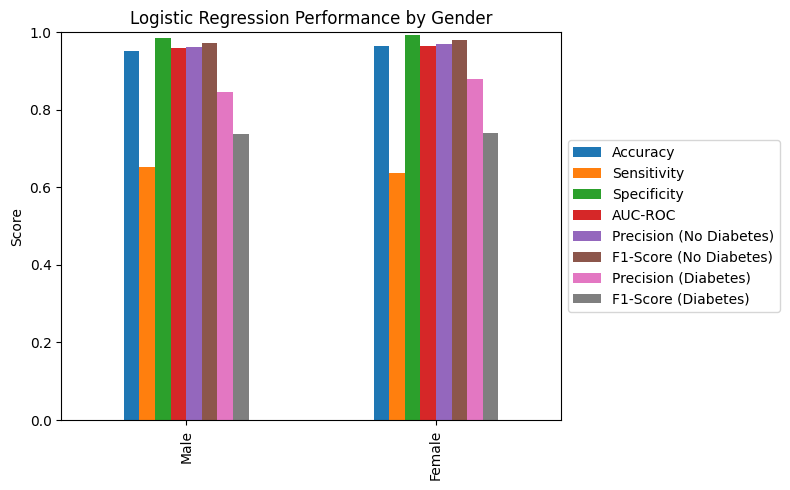

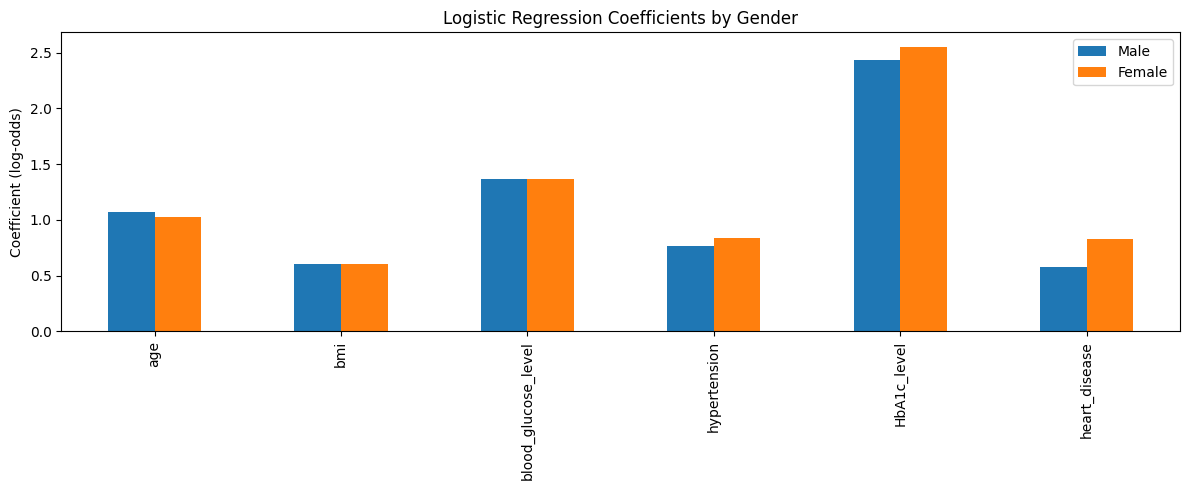

In [15]:
#plots
ax = metrics_df3.plot.bar(figsize=(8,5))
ax.set_title("Logistic Regression Performance by Gender")
ax.set_ylim(0,1)
ax.set_ylabel("Score")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

coef_compare[['Male','Female']].plot.bar(figsize=(12,5))
plt.title("Logistic Regression Coefficients by Gender")
plt.ylabel("Coefficient (log-odds)")
plt.tight_layout()
plt.show()

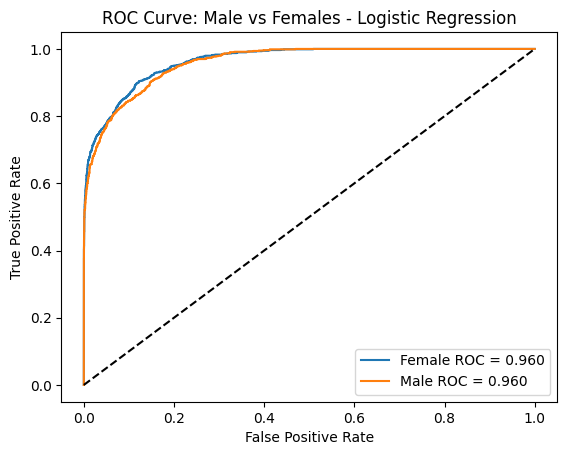

In [ ]:
#ROC curve to compare gender
fpr, tpr, thresholds = roc_curve(y_female_test, y_prob) 
fpr2, tpr2, thresholds2 = roc_curve(y_male_test, y_prob2) 
plt.plot(fpr, tpr, label=f"Female ROC = {auc:.3f}")
plt.plot(fpr2, tpr2, label=f"Male ROC = {auc:.3f}")
plt.plot([0,1], [0,1], 'k--')  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Male vs Females - Logistic Regression")
plt.legend()
plt.show()